In [1]:
!pip install -U "protobuf<5" --force-reinstall --quiet
!pip install -U tensorflow --quiet
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 6.0 MB/s eta 0:00:00a 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
a2a-sdk 0.3.10 requires protobuf>=5.29.5, but you have protobuf 4.25.8 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 46.0.3 which is incompatible.
pydrive2 1.21.3 requires pyOpenSSL<=24.2.1,>=19.1.0, but you have pyopenssl 25.3.0 which is incompatible.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you h

In [2]:
# LIBRARIES
import random
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from pathlib import Path
from skimage import color
import kagglehub

In [3]:
# DATASET
dataset_path = Path(kagglehub.dataset_download("akash2sharma/tiny-imagenet"))
tiny_path = dataset_path / "tiny-imagenet-200"
print("Dataset downloaded to:", tiny_path)

Dataset downloaded to: /kaggle/input/tiny-imagenet/tiny-imagenet-200


In [4]:
# GLOBAL PARAMETERS
IMG_SIZE = 64
N_BINS = 64
NUM_CLASSES = N_BINS * N_BINS

In [5]:
# DISCRETIZING AND PREPROCESSING FUNCTIONS
# Discretize ab values into discrete bins
def quantize_ab(ab):
    a = np.clip(((ab[...,0] + 1) / 2) * (N_BINS - 1), 0, N_BINS - 1).astype(int)
    b = np.clip(((ab[...,1] + 1) / 2) * (N_BINS - 1), 0, N_BINS - 1).astype(int)
    return a * N_BINS + b

# Convert discrete bins to continuous ab values
def dequantize_ab(label):
    a = (label // N_BINS) / (N_BINS - 1) * 2 - 1
    b = (label % N_BINS) / (N_BINS - 1) * 2 - 1
    return np.stack([a, b], axis=-1)

# RGB -> Lab -> L + ab bin
def load_and_preprocess_image(img_path):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    lab = color.rgb2lab(img).astype("float32")
    L = lab[:, :, 0:1] / 100.0              
    ab = lab[:, :, 1:] / 128.0              

    label = quantize_ab(ab)
    return L, label, ab

In [6]:
# PER-CLASS SAMPLE + PER-CLASS 80/20 SPLIT
def sample_subset_split(source_dir, num_classes, samples_per_class, seed=42):
    random.seed(seed)
    train_dir = source_dir / "train"
    all_classes = sorted([c for c in train_dir.iterdir() if c.is_dir()])
    chosen_classes = random.sample(all_classes, num_classes)
    train_paths, val_paths = [], []

    for cls in chosen_classes:
        imgs = list((cls / "images").glob("*.JPEG"))
        imgs = random.sample(imgs, min(samples_per_class, len(imgs)))
        split = int(0.8 * len(imgs))
        train_paths.extend(imgs[:split])
        val_paths.extend(imgs[split:])
    return train_paths, val_paths

train_paths, val_paths = sample_subset_split(
    tiny_path, num_classes=100, samples_per_class=200
)
print(f"Train images: {len(train_paths)}, Val images: {len(val_paths)}")

def create_dataset(paths):
    Ls, labels, abs_ = [], [], []
    for p in paths:
        L, label, ab = load_and_preprocess_image(p)
        Ls.append(L)
        labels.append(label)
        abs_.append(ab)
    return np.array(Ls), np.array(labels), np.array(abs_)

X_train, Y_train_cls, Y_train_reg = create_dataset(train_paths)
X_val, Y_val_cls, Y_val_reg = create_dataset(val_paths)

print("Shapes:")
print("X_train:", X_train.shape)
print("Y_train_cls:", Y_train_cls.shape)
print("Y_train_reg:", Y_train_reg.shape)

Train images: 16000, Val images: 4000
Shapes:
X_train: (16000, 64, 64, 1)
Y_train_cls: (16000, 64, 64)
Y_train_reg: (16000, 64, 64, 2)


In [7]:
# HYBRID U-NET 
def unet_hybrid(output_classes=NUM_CLASSES):
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

    # Encoder
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D(2)(c1)

    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D(2)(c2)

    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D(2)(c3)

    # Bottleneck
    bn = layers.Conv2D(512, 3, activation='relu', padding='same')(p3)
    bn = layers.Conv2D(512, 3, activation='relu', padding='same')(bn)

    # Decoder
    u1 = layers.UpSampling2D(2)(bn)
    u1 = layers.concatenate([u1, c3])
    c4 = layers.Conv2D(256, 3, activation='relu', padding='same')(u1)

    u2 = layers.UpSampling2D(2)(c4)
    u2 = layers.concatenate([u2, c2])
    c5 = layers.Conv2D(128, 3, activation='relu', padding='same')(u2)

    u3 = layers.UpSampling2D(2)(c5)
    u3 = layers.concatenate([u3, c1])
    c6 = layers.Conv2D(64, 3, activation='relu', padding='same')(u3)

    # Output heads
    cls_out = layers.Conv2D(output_classes, 1, activation='softmax', name="cls_out")(c6)
    reg_out = layers.Conv2D(2, 1, activation='tanh', name="reg_out")(c6)

    return models.Model(inputs, [cls_out, reg_out])

In [19]:
model = unet_hybrid()
lambda_reg = 0.3  # weight for regression loss

model.compile(
    optimizer='adam',
    loss={
        "cls_out": "sparse_categorical_crossentropy",
        "reg_out": "mse",
    },
    loss_weights={
        "cls_out": 1.0,
        "reg_out": lambda_reg,
    }
)

history = model.fit(
    X_train,
    {"cls_out": Y_train_cls, "reg_out": Y_train_reg},
    validation_data=(X_val, {"cls_out": Y_val_cls, "reg_out": Y_val_reg}),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 134s 255ms/step - cls_out_loss: 4.9379 - loss: 4.9546 - reg_out_loss: 0.0557 - val_cls_out_loss: 4.7996 - val_loss: 4.8044 - val_reg_out_loss: 0.0161
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 137s 274ms/step - cls_out_loss: 4.6470 - loss: 4.6520 - reg_out_loss: 0.0168 - val_cls_out_loss: 4.6288 - val_loss: 4.6337 - val_reg_out_loss: 0.0164
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 146s 291ms/step - cls_out_loss: 4.6012 - loss: 4.6058 - reg_out_loss: 0.0154 - val_cls_out_loss: 4.5771 - val_loss: 4.5823 - val_reg_out_loss: 0.0173
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 148s 297ms/step - cls_out_loss: 4.5811 - loss: 4.5856 - reg_out_loss: 0.0147 - val_cls_out_loss: 4.5596 - val_loss: 4.5635 - val_reg_out_loss: 0.0130
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 150s 300ms/step - cls_out_loss: 4.5550 - loss: 4.5594 - reg_out_loss: 0.0147 - val_cls_out_loss: 4.5315 - val_loss: 4.5361 - val_reg_out_loss: 0.0151
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 150s 301ms

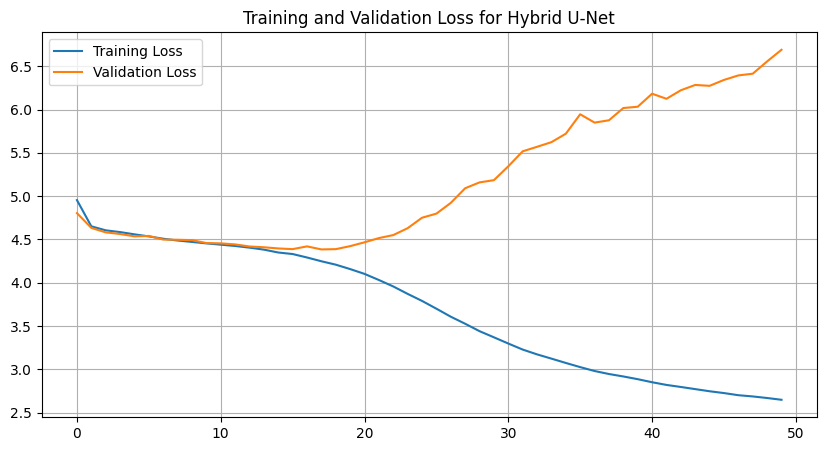

In [30]:
plt.figure(figsize=(10,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
# plt.plot(history.history["loss"], label="Total Loss")
plt.legend()
plt.title("Training and Validation Loss for Hybrid U-Net")
plt.grid()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 889ms/step


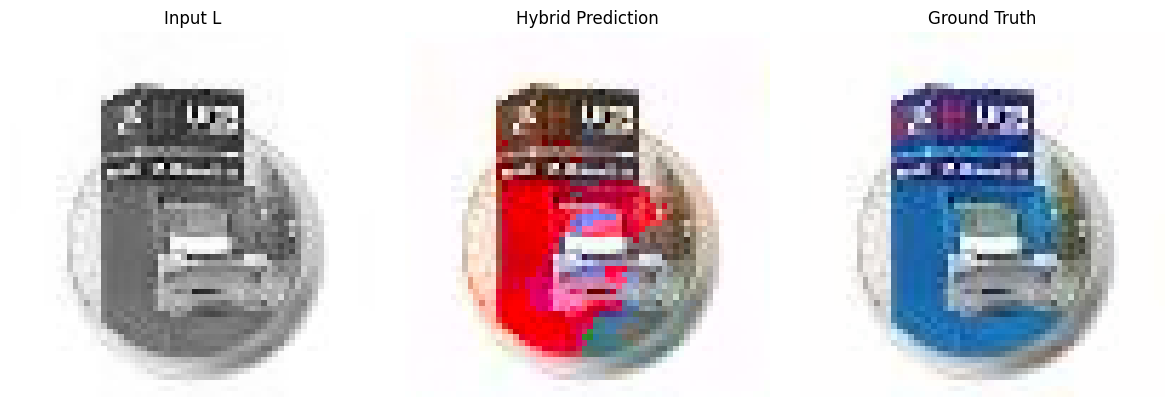

In [ ]:
def lab_to_rgb(L, ab):
    L2 = L * 100
    ab2 = ab * 128
    lab = np.concatenate([L2, ab2], axis=-1)
    rgb = color.lab2rgb(lab) 
    return np.clip(rgb, 0, 1)

idx = np.random.randint(0, len(X_val))
L = X_val[idx:idx+1]
cls_pred, reg_pred = model.predict(L)

labels = np.argmax(cls_pred[0], axis=-1)
ab_coarse = dequantize_ab(labels)

ab_final = ab_coarse + reg_pred[0]
ab_final = np.clip(ab_final, -1, 1)

rgb_pred = lab_to_rgb(L[0], ab_final)

# Ground truth
rgb_true = lab_to_rgb(L[0], Y_val_reg[idx])

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(np.repeat(L[0], 3, axis=-1))
plt.title("Input L")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(rgb_pred)
plt.title("Hybrid Prediction")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(rgb_true)
plt.title("Ground Truth")
plt.axis("off")

plt.tight_layout()
plt.show()

Loading images and ground truth...
Processing 10 images...


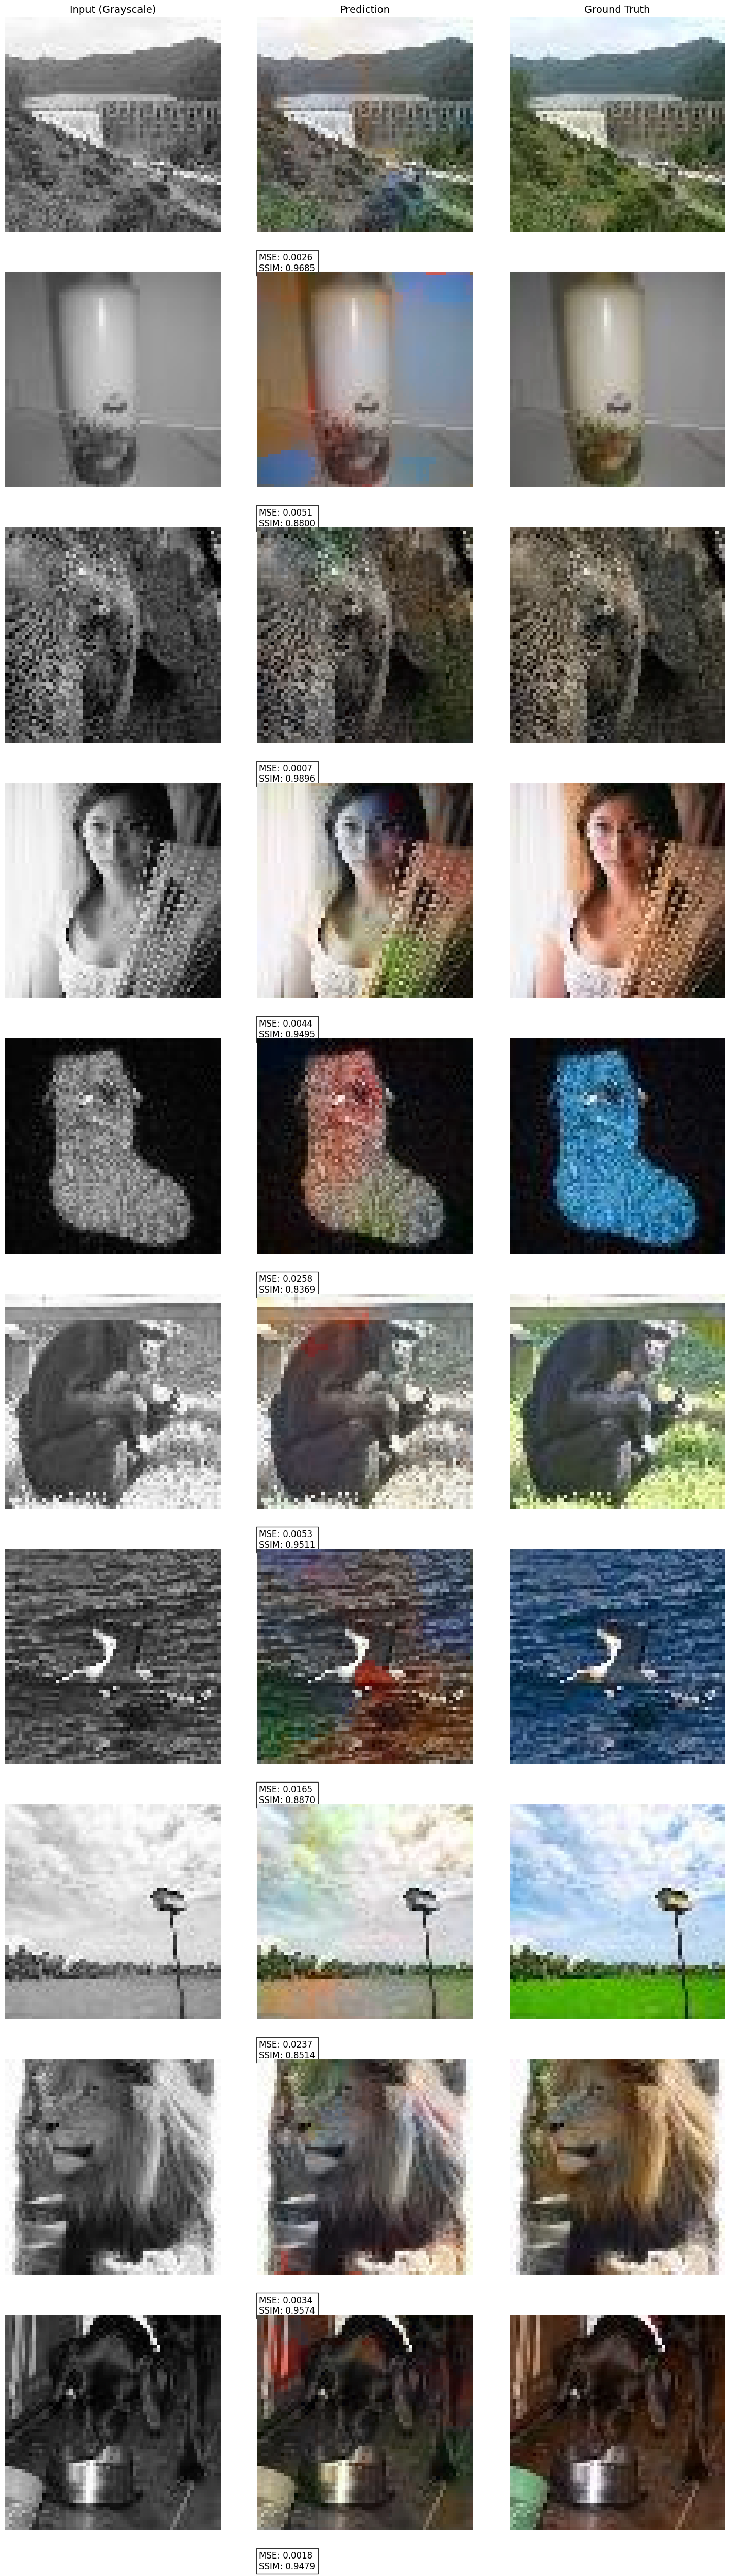

In [ ]:
N_BINS = 64 

image_files = [
    '/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_1018.JPEG',
    '/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_0.JPEG',
    '/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_1078.JPEG',
    '/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_1103.JPEG',
    '/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_1129.JPEG',
    '/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_1186.JPEG',
    '/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_1202.JPEG',
    '/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_132.JPEG',
    '/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_1314.JPEG',
    '/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_2005.JPEG'
]

def dequantize_ab(label):
    a = (label // N_BINS) / (N_BINS - 1) * 2 - 1
    b = (label % N_BINS) / (N_BINS - 1) * 2 - 1
    return np.stack([a, b], axis=-1)

def lab_to_rgb(L, ab):
    L2 = L * 100
    ab2 = ab * 128
    lab = np.concatenate([L2, ab2], axis=-1)
    rgb = color.lab2rgb(lab)
    return np.clip(rgb, 0, 1)

def process_image_with_gt(img_path):
    if not os.path.exists(img_path): return None, None
    try:
        img = Image.open(img_path).convert('RGB').resize((64, 64))
        img = np.array(img)
        lab = color.rgb2lab(img).astype("float32")
        L = lab[:, :, 0:1] / 100.0
        ab = lab[:, :, 1:] / 128.0
        return L, ab
    except: return None, None

X_input = []
ab_true_list = []
valid_indices = []

print("Loading images and ground truth...")
for i, p in enumerate(image_files):
    L, ab = process_image_with_gt(p)
    if L is not None:
        X_input.append(L)
        ab_true_list.append(ab)
        valid_indices.append(i)
X_input = np.array(X_input)
ab_true_list = np.array(ab_true_list)

if len(X_input) > 0:
    print(f"Processing {len(X_input)} images...")
    preds = model.predict(X_input, verbose=0)
    out1, out2 = preds
    if out1.shape[-1] == 2: 
        reg_pred_batch, cls_pred_batch = out1, out2
    else:
        cls_pred_batch, reg_pred_batch = out1, out2

    num_samples = len(X_input)
    plt.figure(figsize=(15, 5 * num_samples))

    for i in range(num_samples):
        L_img = X_input[i]
        ab_true = ab_true_list[i]
        cls_pred = cls_pred_batch[i]
        reg_pred = reg_pred_batch[i]
        labels = np.argmax(cls_pred, axis=-1)
        ab_coarse = dequantize_ab(labels)
        ab_final = (ab_coarse * 0.5) + (reg_pred * 0.5)
        ab_final = np.clip(ab_final, -1, 1)
        rgb_input = np.repeat(L_img, 3, axis=-1)
        rgb_pred = lab_to_rgb(L_img, ab_final)
        rgb_true = lab_to_rgb(L_img, ab_true)
        mse_val = mean_squared_error(rgb_true.flatten(), rgb_pred.flatten())
        ssim_val = ssim(rgb_true, rgb_pred, channel_axis=-1, data_range=1.0)

        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(rgb_input)
        plt.axis('off')
        if i == 0: plt.title("Input (Grayscale)", fontsize=14)
        
        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(rgb_pred)
        plt.axis('off')
        if i == 0: plt.title("Prediction", fontsize=14)
        plt.text(0, 75, f"MSE: {mse_val:.4f}\nSSIM: {ssim_val:.4f}", 
                 fontsize=12, backgroundcolor='white', bbox=dict(facecolor='white', alpha=0.8))

        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(rgb_true)
        plt.axis('off')
        if i == 0: plt.title("Ground Truth", fontsize=14)

    plt.tight_layout()
    plt.show()